<a href="https://colab.research.google.com/github/huuthoth/10x_VisiumHD_Mouse_Brain_Spatial_Transcriptomics_Self-Guided/blob/main/BIOF510_project_report_Nguyen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Full pipeline to train a classifier on adult scRNA-seq cell types
and predict cell types in larval scRNA-seq data.

- The adult and larval ventral cord datasets are publicly available and have been converted from Seurat objects into AnnData objects

- Adult labels stored in: adult.obs["Celltypes"]
- Goal: predict adult-defined cell types for larval cells.



**Approach** **1: supervised learning**

Requirements:
- scanpy
- scikit-learn
- numpy
- pandas


In [ ]:
pip install scanpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.5 MB/s eta 0:00:00


In [ ]:
!pip install scikit-misc


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 7.7 MB/s eta 0:00:00


In [ ]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


The adult and larval ventral cord datasets are publicly available (Nguyen et al., 2024 and Allen et al., 2020) and have been converted from Seurat objects into AnnData objects by R code

In [ ]:
# Load data
adult = sc.read_h5ad("/content/drive/MyDrive/Notebooks/Adult_VNC.h5ad")
larval = sc.read_h5ad("/content/drive/MyDrive/Notebooks/larval_VNC.h5ad")


In [ ]:
#structure of larval and adult data
print("Adult:", adult)
print("Larval:", larval)


Adult: AnnData object with n_obs × n_vars = 26767 × 13204
    obs: 'nCount_RNA', 'nFeature_RNA', 'Replicate', 'prop.mito', 'Sex', 'integrated_snn_res.2', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.5', 'integrated_snn_res.0.8', 'integrated_snn_res.1.5', 'integrated_snn_res.2.5', 'Celltypes'
    var: 'name'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
Larval: AnnData object with n_obs × n_vars = 11910 × 12753
    obs: 'Sample', 'Barcode', 'total_features_by_counts', 'log10_total_features_by_counts', 'total_counts', 'log10_total_counts', 'pct_counts_in_top_50_features', 'pct_counts_in_top_100_features', 'pct_counts_in_top_200_features', 'pct_counts_in_top_500_features', 'total_features_by_counts_endogenous', 'log10_total_features_by_counts_endogenous', 'total_counts_endogenous', 'log10_total_counts_endogenous', 'pct_counts_endogenous', 'pct_counts_in_top_50_features_endogenous', 'pct_counts_in_top_100_features_endogenous', 'pct_counts_in_top_200_features_endogenous', 'pct_c

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

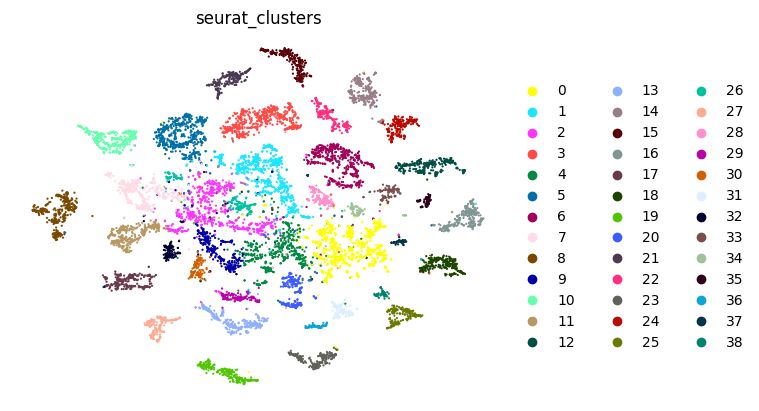

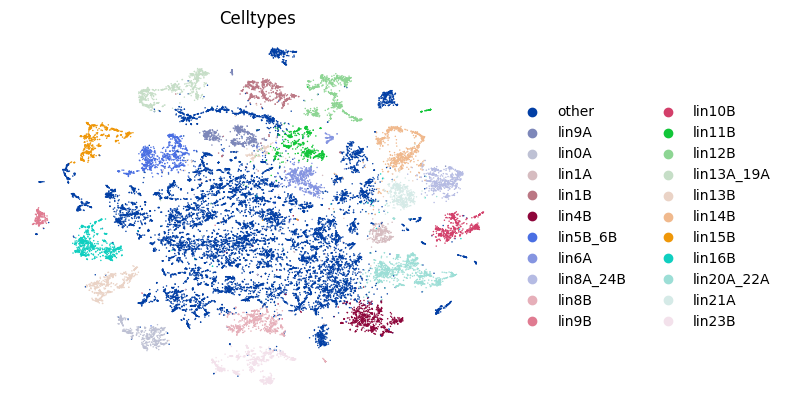

In [ ]:
#tSNE plot of the cells in larval and adult data
import matplotlib.pyplot as plt
fig = sc.pl.tsne(
    larval,
    color=["seurat_clusters"],
    frameon=False,
    ncols=1,
    return_fig=True
)

fig.savefig("larval_tsne.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("larval_tsne.png")


fig = sc.pl.tsne(
    adult,
    color=["Celltypes"],
    frameon=False,
    ncols=1,
    return_fig=True
)

fig.savefig("adult_tsne.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("adult_tsne.png")


In [ ]:

adult.layers["counts"] = adult.X.copy()
sc.pp.normalize_total(adult, target_sum=1e4)
sc.pp.log1p(adult)
adult.raw = adult

sc.pp.highly_variable_genes(adult, flavor = 'seurat_v3', n_top_genes=2000,
                            layer = "counts")


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [ ]:
larval.layers["counts"] = larval.X.copy()
sc.pp.normalize_total(larval, target_sum=1e4)
sc.pp.log1p(larval)
larval.raw = larval

sc.pp.highly_variable_genes(larval, flavor = 'seurat_v3', n_top_genes=2000,
                            layer = "counts")




/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [ ]:
#Prepare features and labels

# Get the list of HVGs
hvg1 = larval.var_names[larval.var['highly_variable']].tolist()
hvg2 = adult.var_names[adult.var['highly_variable']].tolist()

# Find the intersection (common HVGs)
common_genes = list(set(hvg1).intersection(set(hvg2)))
print(f"Number of common genes: {len(common_genes)}")


Number of common genes: 588


In [ ]:

adult_hvg = adult[:, common_genes].copy()
larval_hvg = larval[:, common_genes].copy()


In [ ]:
X_adult = adult_hvg.X
y_adult = adult_hvg.obs["Celltypes"].astype(str).values


In [ ]:
# Encode labels
le = LabelEncoder()
y_adult_encoded = le.fit_transform(y_adult)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_adult, y_adult_encoded, test_size=0.2, random_state=42
)

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
X_larval = larval_hvg.X
y_larval_pred = clf.predict(X_larval)

# Convert back to labels
y_larval_labels = le.inverse_transform(y_larval_pred)



In [ ]:
# Evaluate on adult test set
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

report_dict = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)


              precision    recall  f1-score   support

       lin0A       0.96      0.45      0.61       107
      lin10B       0.94      0.61      0.74       100
      lin11B       0.98      0.32      0.49       133
      lin12B       1.00      0.42      0.59       176
  lin13A_19A       0.98      0.80      0.88       145
      lin13B       0.97      0.45      0.61       132
      lin14B       0.95      0.48      0.64       153
      lin15B       0.96      0.60      0.74       125
      lin16B       0.94      0.79      0.86       155
       lin1A       1.00      0.07      0.13        58
       lin1B       0.97      0.46      0.63       125
  lin20A_22A       0.95      0.76      0.85       217
      lin21A       1.00      0.03      0.06        92
      lin23B       0.98      0.75      0.85       166
       lin4B       0.90      0.57      0.70       148
    lin5B_6B       0.94      0.30      0.45       202
       lin6A       0.97      0.46      0.62       126
   lin8A_24B       0.92    

In [ ]:
# Learning Curve (Training vs Validation Accuracy)
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    clf,
    X_adult,
    y_adult_encoded,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


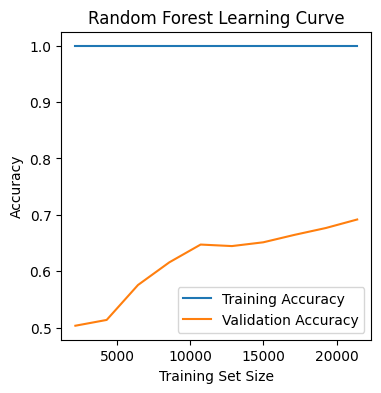

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

# Compute means and std dev
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
# Plot Learning Curve
fig = plt.figure(figsize=(4, 4))
plt.plot(train_sizes, train_mean, label="Training Accuracy")
plt.plot(train_sizes, val_mean, label="Validation Accuracy")

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.show()

# Save figure
fig.savefig("RF_larval_learning_curve.png", dpi=300, bbox_inches="tight")

# Download
from google.colab import files
files.download("RF_larval_learning_curve.png")



In [ ]:
larval.obs["predicted_celltype"] = y_larval_labels


In [ ]:
larval.obs["predicted_celltype"].value_counts()

,count
predicted_celltype,
other,9849
lin20A_22A,365
lin4B,298
lin16B,267
lin14B,173
lin23B,161
lin0A,152
lin1B,143
lin6A,140


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

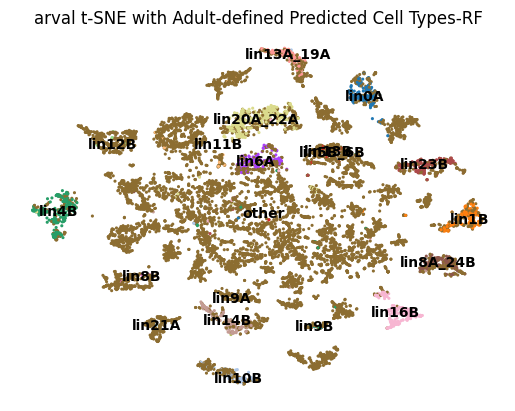

In [ ]:
fig = sc.pl.tsne(larval,
    color="predicted_celltype",
    frameon=False,
    legend_loc="on data",
    title="arval t-SNE with Adult-defined Predicted Cell Types-RF",
    size=20,
    return_fig=True)

# Save figure
fig.savefig("RF_larval_tsne.png", dpi=300, bbox_inches="tight")

# Download to local computer
from google.colab import files
files.download("RF_larval_tsne.png")

**Approach** **2: Build Neural Network Model**

Require:
- scanpy
- tensorflow
- scikit-learn
- numpy
- pandas

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [ ]:
!pip install scikit-misc
!pip install cython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 4.9 MB/s eta 0:00:00


In [ ]:
# Load data
adult = sc.read_h5ad("/content/drive/MyDrive/Notebooks/Adult_VNC.h5ad")
larval = sc.read_h5ad("/content/drive/MyDrive/Notebooks/larval_VNC.h5ad")
# Print the data
print(adult)
print(larval)

AnnData object with n_obs × n_vars = 26767 × 13204
    obs: 'nCount_RNA', 'nFeature_RNA', 'Replicate', 'prop.mito', 'Sex', 'integrated_snn_res.2', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.5', 'integrated_snn_res.0.8', 'integrated_snn_res.1.5', 'integrated_snn_res.2.5', 'Celltypes'
    var: 'name'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
AnnData object with n_obs × n_vars = 11910 × 12753
    obs: 'Sample', 'Barcode', 'total_features_by_counts', 'log10_total_features_by_counts', 'total_counts', 'log10_total_counts', 'pct_counts_in_top_50_features', 'pct_counts_in_top_100_features', 'pct_counts_in_top_200_features', 'pct_counts_in_top_500_features', 'total_features_by_counts_endogenous', 'log10_total_features_by_counts_endogenous', 'total_counts_endogenous', 'log10_total_counts_endogenous', 'pct_counts_endogenous', 'pct_counts_in_top_50_features_endogenous', 'pct_counts_in_top_100_features_endogenous', 'pct_counts_in_top_200_features_endogenous', 'pct_counts_in_top_50

In [ ]:

adult.layers["counts"] = adult.X.copy()
sc.pp.normalize_total(adult, target_sum=1e4)
sc.pp.log1p(adult)
adult.raw = adult

sc.pp.highly_variable_genes(adult, flavor = 'seurat_v3', n_top_genes=2000,
                            layer = "counts")



/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [ ]:
larval.layers["counts"] = larval.X.copy()
sc.pp.normalize_total(larval, target_sum=1e4)
sc.pp.log1p(larval)
larval.raw = larval

sc.pp.highly_variable_genes(larval, flavor = 'seurat_v3', n_top_genes=2000,
                            layer = "counts")




/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [ ]:
#Prepare features and labels

# Get the list of HVGs
hvg1 = larval.var_names[larval.var['highly_variable']].tolist()
hvg2 = adult.var_names[adult.var['highly_variable']].tolist()

# Find the intersection (common HVGs)
common_genes = list(set(hvg1).intersection(set(hvg2)))
print(f"Number of common genes: {len(common_genes)}")




Number of common genes: 604


In [ ]:
# Subset and order genes identically
X_larval = larval[:, common_genes].X.toarray() if hasattr(larval[:, common_genes].X, "toarray") else larval[:, common_genes].X
y_adult = adult.obs["Celltypes"].values  # target labels from adult

# Encode labels as integers
le = LabelEncoder()
y_encoded = le.fit_transform(y_adult)

In [ ]:
# Split data into train/val/test
# X_adult features
X_adult = adult[:, common_genes].X.toarray() if hasattr(adult[:, common_genes].X, "toarray") else adult[:, common_genes].X

# y_adult labels
y_adult = adult.obs["Celltypes"].values
y_encoded = LabelEncoder().fit_transform(y_adult)

# Split adult dataset into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_adult, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)



In [ ]:
#Define model parameters
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_encoded))

In [ ]:


model = Sequential([
    Dense(512, activation='relu', kernel_regularizer=l2(1e-4), input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.10),

    Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.10),


    Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.10),

    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.10),


    Dense(32, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.10),

    Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.10),

    Dense(8, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.10),

    Dense(num_classes, activation='softmax')
])


# Compile
optimizer = Adam(learning_rate=1e-4)  # Lower LR improves stability
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.0348 - loss: 3.3604 - val_accuracy: 0.0498 - val_loss: 3.0713
Epoch 2/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1252 - loss: 3.0695 - val_accuracy: 0.3910 - val_loss: 2.7818
Epoch 3/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.3608 - loss: 2.8056 - val_accuracy: 0.5233 - val_loss: 2.5099
Epoch 4/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4761 - loss: 2.5545 - val_accuracy: 0.5636 - val_loss: 2.2405
Epoch 5/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5269 - loss: 2.3246 - val_accuracy: 0.6045 - val_loss: 2.0083
Epoch 6/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5597 - loss: 2.0778 - val_accuracy: 0.6443 - val_loss: 1.8006
Epoch 7/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.5861 - loss: 1.9158 - val_accuracy: 0.6653 - val_loss: 1.6651
Epoch 8/80
293/293 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6174 - loss: 1.7548 - val_ac

In [ ]:
# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test accuracy:", test_acc)


126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9251 - loss: 0.5223
Test accuracy: 0.9188246726989746


In [ ]:
#predict on new larval data
y_pred = model.predict(X_test)
y_pred_labels = le.inverse_transform(np.argmax(y_pred, axis=1))

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


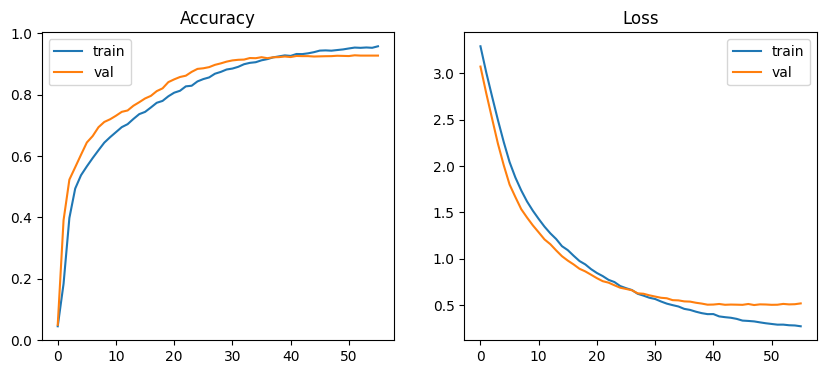

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

# Create figure and keep reference
fig = plt.figure(figsize=(10,4))

# Accuracy subplot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])

# Loss subplot
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])

# Show plot
plt.show()

# Save the plot
fig.savefig("training_curves.png", dpi=300, bbox_inches="tight")

# Download
from google.colab import files
files.download("training_curves.png")

In [ ]:
#Predict and examine confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       0.84      0.91      0.87        80
           1       0.95      0.98      0.96        83
           2       0.81      0.84      0.82       106
           3       0.97      0.92      0.95       123
           4       0.91      0.97      0.94       106
           5       0.85      0.89      0.87       102
           6       0.90      0.92      0.91       113
           7       0.94      0.95      0.94        93
           8       0.94      0.96      0.95       113
           9       0.88      0.82      0.85        45
          10       0.82      0.87      0.85        92
          11       0.93      0.87      0.90       155
          12       0.75      0.84      0.79        67
          13       0.97      0.96      0.96       120
          14       0.83      0.90      0.86       109
          15       0.90      0.93      0.91       138
          16       0.84      0.89      0

In [ ]:
common_genes = list(set(hvg1).intersection(set(hvg2)))

# align features
X_larval = larval[:, common_genes].X.toarray() if hasattr(larval[:, common_genes].X, "toarray") \
           else larval[:, common_genes].X

# Predict
y_larval_pred = model.predict(X_larval)
y_larval_labels = le.inverse_transform(np.argmax(y_larval_pred, axis=1))


373/373 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
larval.obs["predicted_celltype"] = y_larval_labels


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

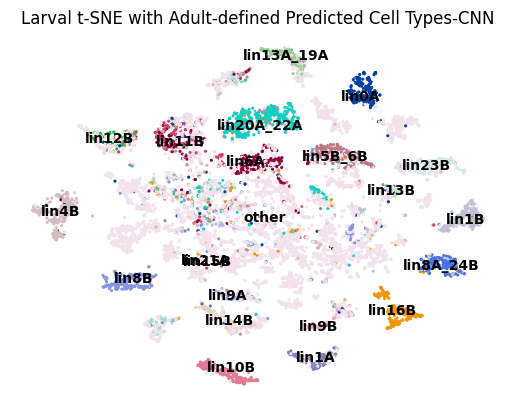

In [ ]:
fig = sc.pl.tsne(larval,
    color="predicted_celltype",
    frameon=False,
    legend_loc="on data",
    title="Larval t-SNE with Adult-defined Predicted Cell Types-CNN",
    size=20,
    return_fig=True)

# Save figure
fig.savefig("CNN_larval_tsne.png", dpi=300, bbox_inches="tight")

# Download to local computer
from google.colab import files
files.download("CNN_larval_tsne.png")

In [ ]:
larval.obs['predicted_celltype'].value_counts()


,count
predicted_celltype,
other,6839
lin20A_22A,632
lin4B,418
lin10B,391
lin6A,384
lin8B,366
lin16B,365
lin0A,343
lin1B,282


**Approach** **3: Using common scVI method**

Require:
- scanpy
- tensorflow
- scikit-learn
- numpy
- pandas
- scvi

*   The codes were adapted from https://github.com/mousepixels/sanbomics_scripts/blob/main/scvi_label_transfer.ipynb

In [ ]:
!pip install --quiet scvi-colab
from scvi_colab import install

install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


/usr/local/lib/python3.12/dist-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


In [ ]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch
from rich import print
from scib_metrics.benchmark import Benchmarker

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Load data
adult = sc.read_h5ad("/content/drive/MyDrive/Notebooks/Adult_VNC.h5ad")
larval = sc.read_h5ad("/content/drive/MyDrive/Notebooks/larval_VNC.h5ad")

Mounted at /content/drive


In [ ]:
adult


AnnData object with n_obs × n_vars = 26767 × 13204
    obs: 'nCount_RNA', 'nFeature_RNA', 'Replicate', 'prop.mito', 'Sex', 'integrated_snn_res.2', 'seurat_clusters', 'integrated_snn_res.1', 'integrated_snn_res.0.5', 'integrated_snn_res.0.8', 'integrated_snn_res.1.5', 'integrated_snn_res.2.5', 'Celltypes'
    var: 'name'
    obsm: 'X_pca', 'X_tsne', 'X_umap'

In [ ]:
larval

AnnData object with n_obs × n_vars = 11910 × 12753
    obs: 'Sample', 'Barcode', 'total_features_by_counts', 'log10_total_features_by_counts', 'total_counts', 'log10_total_counts', 'pct_counts_in_top_50_features', 'pct_counts_in_top_100_features', 'pct_counts_in_top_200_features', 'pct_counts_in_top_500_features', 'total_features_by_counts_endogenous', 'log10_total_features_by_counts_endogenous', 'total_counts_endogenous', 'log10_total_counts_endogenous', 'pct_counts_endogenous', 'pct_counts_in_top_50_features_endogenous', 'pct_counts_in_top_100_features_endogenous', 'pct_counts_in_top_200_features_endogenous', 'pct_counts_in_top_500_features_endogenous', 'total_features_by_counts_feature_control', 'log10_total_features_by_counts_feature_control', 'total_counts_feature_control', 'log10_total_counts_feature_control', 'pct_counts_feature_control', 'pct_counts_in_top_50_features_feature_control', 'pct_counts_in_top_100_features_feature_control', 'total_features_by_counts_Mt', 'log10_total

In [ ]:
larval.var_names_make_unique()


In [ ]:
larval = larval.concatenate(adult)
larval.obs


/tmp/ipython-input-3299575130.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  larval = larval.concatenate(adult)


,Sample,Barcode,total_features_by_counts,log10_total_features_by_counts,total_counts,log10_total_counts,pct_counts_in_top_50_features,pct_counts_in_top_100_features,pct_counts_in_top_200_features,pct_counts_in_top_500_features,...,integrated_snn_res.0.35,integrated_snn_res.0.8,Replicate,prop.mito,Sex,integrated_snn_res.2,integrated_snn_res.1.5,integrated_snn_res.2.5,Celltypes,batch
cell_15_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAACCTGTCTTGTATC-1,1886.0,3.275772,6234.0,3.794836,34.055181,47.224896,59.720885,73.724735,...,8,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
cell_19_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAACGGGAGGAGCGAG-1,1288.0,3.110253,3413.0,3.533264,39.408145,51.010841,62.525637,76.911808,...,8,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
cell_134_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AACTCAGTCGGAAACG-1,1562.0,3.193959,4775.0,3.679064,37.465969,49.675393,61.382199,76.167539,...,8,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
cell_193_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAGACCTTCTGAGGGA-1,2158.0,3.334253,6878.0,3.837525,31.986042,43.849956,56.033731,70.514685,...,8,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
cell_203_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAGCCGCGTGGCCCTA-1,1326.0,3.122871,3507.0,3.545060,34.616481,47.419447,60.136869,76.447106,...,8,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
male1_rep2_CGTGAGCGTCGGGTCT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,14,rep4,5.584281,male,25,16,15,lin6A,1
male1_rep2_CCGGTAGAGCCGTCGT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3,rep4,3.068712,male,3,29,31,lin20A_22A,1
male1_rep2_GGCGTGTAGTGTCCAT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4,rep4,2.411995,male,22,10,9,other,1
male1_rep2_GTCGGGTAGGCGATAC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1,rep4,7.529090,male,1,0,0,other,1


In [ ]:
larval.layers["counts"] = larval.X.copy()
sc.pp.normalize_total(larval, target_sum=1e4)
sc.pp.log1p(larval)
larval.raw = larval

sc.pp.highly_variable_genes(larval, flavor = 'seurat_v3', n_top_genes=2000,
                            layer = "counts", batch_key="batch", subset = True)


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


In [ ]:
scvi.model.SCVI.setup_anndata(larval, layer = 'counts', batch_key='batch')
vae = scvi.model.SCVI(larval)
vae.train(max_epochs=100, early_stopping=True)



/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Training:   0%|          | 0/100 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_vae.py:570: UserWarning: The value argument must be within the 

In [ ]:
larval.obs['Celltypes'] = larval.obs['Celltypes'].cat.add_categories('Unknown')
larval.obs = larval.obs.fillna(value = {'Celltypes': 'Unknown'})
larval.obs

,Sample,Barcode,total_features_by_counts,log10_total_features_by_counts,total_counts,log10_total_counts,pct_counts_in_top_50_features,pct_counts_in_top_100_features,pct_counts_in_top_200_features,pct_counts_in_top_500_features,...,Replicate,prop.mito,Sex,integrated_snn_res.2,integrated_snn_res.1.5,integrated_snn_res.2.5,Celltypes,batch,_scvi_batch,_scvi_labels
cell_15_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAACCTGTCTTGTATC-1,1886.0,3.275772,6234.0,3.794836,34.055181,47.224896,59.720885,73.724735,...,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,0
cell_19_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAACGGGAGGAGCGAG-1,1288.0,3.110253,3413.0,3.533264,39.408145,51.010841,62.525637,76.911808,...,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,0
cell_134_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AACTCAGTCGGAAACG-1,1562.0,3.193959,4775.0,3.679064,37.465969,49.675393,61.382199,76.167539,...,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,0
cell_193_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAGACCTTCTGAGGGA-1,2158.0,3.334253,6878.0,3.837525,31.986042,43.849956,56.033731,70.514685,...,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,0
cell_203_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAGCCGCGTGGCCCTA-1,1326.0,3.122871,3507.0,3.545060,34.616481,47.419447,60.136869,76.447106,...,NaN,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
male1_rep2_CGTGAGCGTCGGGTCT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,rep4,5.584281,male,25,16,15,lin6A,1,1,0
male1_rep2_CCGGTAGAGCCGTCGT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,rep4,3.068712,male,3,29,31,lin20A_22A,1,1,0
male1_rep2_GGCGTGTAGTGTCCAT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,rep4,2.411995,male,22,10,9,other,1,1,0
male1_rep2_GTCGGGTAGGCGATAC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,rep4,7.529090,male,1,0,0,other,1,1,0


In [ ]:
lvae = scvi.model.SCANVI.from_scvi_model(vae, adata = larval, unlabeled_category = 'Unknown',
                                        labels_key = 'Celltypes')

lvae.train(max_epochs=50, n_samples_per_label=30, early_stopping=True)


INFO     Training for 50 epochs.                                                                                   


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Training:   0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)
/usr/local/lib/python3.12/dist-packages/scvi/module/_sc

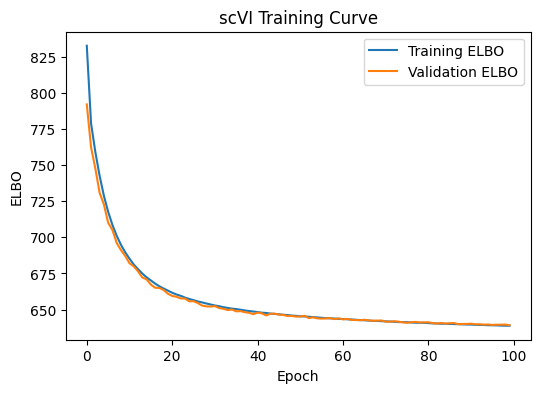

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

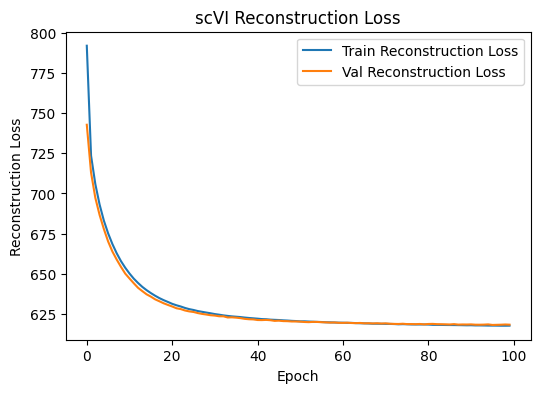

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

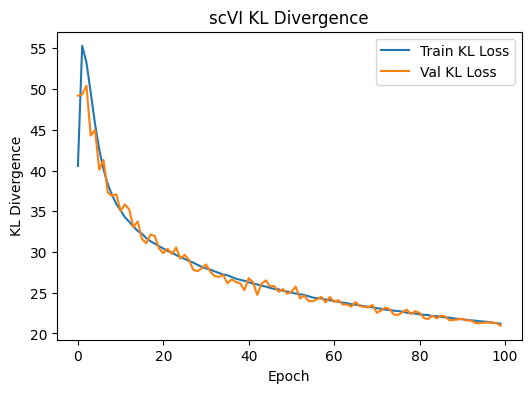

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files

train_history = vae.history

#Save ELBO Curve
fig1 = plt.figure(figsize=(6,4))
plt.plot(train_history["elbo_train"], label="Training ELBO")
plt.plot(train_history["elbo_validation"], label="Validation ELBO")
plt.xlabel("Epoch")
plt.ylabel("ELBO")
plt.title("scVI Training Curve")
plt.legend()
plt.show()

fig1.savefig("scvi_elbo_curve.png", dpi=300, bbox_inches="tight")
files.download("scvi_elbo_curve.png")

#Save Reconstruction Loss
fig2 = plt.figure(figsize=(6,4))
plt.plot(train_history["reconstruction_loss_train"], label="Train Reconstruction Loss")
plt.plot(train_history["reconstruction_loss_validation"], label="Val Reconstruction Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("scVI Reconstruction Loss")
plt.legend()
plt.show()

fig2.savefig("scvi_reconstruction_loss.png", dpi=300, bbox_inches="tight")
files.download("scvi_reconstruction_loss.png")

#Save KL Divergence Plot
fig3 = plt.figure(figsize=(6,4))
plt.plot(train_history["kl_local_train"], label="Train KL Loss")
plt.plot(train_history["kl_local_validation"], label="Val KL Loss")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("scVI KL Divergence")
plt.legend()
plt.show()

fig3.savefig("scvi_kl_divergence.png", dpi=300, bbox_inches="tight")
files.download("scvi_kl_divergence.png")



In [ ]:
larval.obs['predicted'] = lvae.predict(larval)
larval.obs


,Sample,Barcode,total_features_by_counts,log10_total_features_by_counts,total_counts,log10_total_counts,pct_counts_in_top_50_features,pct_counts_in_top_100_features,pct_counts_in_top_200_features,pct_counts_in_top_500_features,...,prop.mito,Sex,integrated_snn_res.2,integrated_snn_res.1.5,integrated_snn_res.2.5,Celltypes,batch,_scvi_batch,_scvi_labels,predicted
cell_15_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAACCTGTCTTGTATC-1,1886.0,3.275772,6234.0,3.794836,34.055181,47.224896,59.720885,73.724735,...,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,22,lin6A
cell_19_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAACGGGAGGAGCGAG-1,1288.0,3.110253,3413.0,3.533264,39.408145,51.010841,62.525637,76.911808,...,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,22,lin8B
cell_134_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AACTCAGTCGGAAACG-1,1562.0,3.193959,4775.0,3.679064,37.465969,49.675393,61.382199,76.167539,...,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,22,lin23B
cell_193_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAGACCTTCTGAGGGA-1,2158.0,3.334253,6878.0,3.837525,31.986042,43.849956,56.033731,70.514685,...,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,22,lin10B
cell_203_1-0,/Users/nguyenhut/Desktop/scRNA/Sc RNA Data-Ser...,AAGCCGCGTGGCCCTA-1,1326.0,3.122871,3507.0,3.545060,34.616481,47.419447,60.136869,76.447106,...,NaN,NaN,NaN,NaN,NaN,Unknown,0,0,22,lin23B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
male1_rep2_CGTGAGCGTCGGGTCT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.584281,male,25,16,15,lin6A,1,1,7,lin6A
male1_rep2_CCGGTAGAGCCGTCGT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.068712,male,3,29,31,lin20A_22A,1,1,19,lin20A_22A
male1_rep2_GGCGTGTAGTGTCCAT-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.411995,male,22,10,9,other,1,1,0,other
male1_rep2_GTCGGGTAGGCGATAC-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.529090,male,1,0,0,other,1,1,0,lin14B


In [ ]:
larval.obs['bc2'] = larval.obs.index.map(lambda x: x[:-2])

cell_mapper = dict(zip(larval.obs.bc2, larval.obs.predicted))

In [ ]:
#map back onto raw adata
larval_ori = sc.read_h5ad("/content/drive/MyDrive/Notebooks/larval_VNC.h5ad")

larval_ori.var_names_make_unique()


In [ ]:
larval_ori.obs['cell_type'] = larval_ori.obs.index.map(cell_mapper)
larval_ori.obs['cell_type']


,cell_type
cell_15_1,lin6A
cell_19_1,lin8B
cell_134_1,lin23B
cell_193_1,lin10B
cell_203_1,lin23B
...,...
cell_4108_5,lin13A_19A
cell_4237_5,lin21A
cell_4333_5,lin13A_19A
cell_4343_5,lin13A_19A


In [ ]:
larval_ori.obs["cell_type"].value_counts()


,count
cell_type,
other,2193
lin20A_22A,966
lin14B,960
lin13A_19A,761
lin6A,668
lin5B_6B,630
lin12B,492
lin8B,484
lin23B,461


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

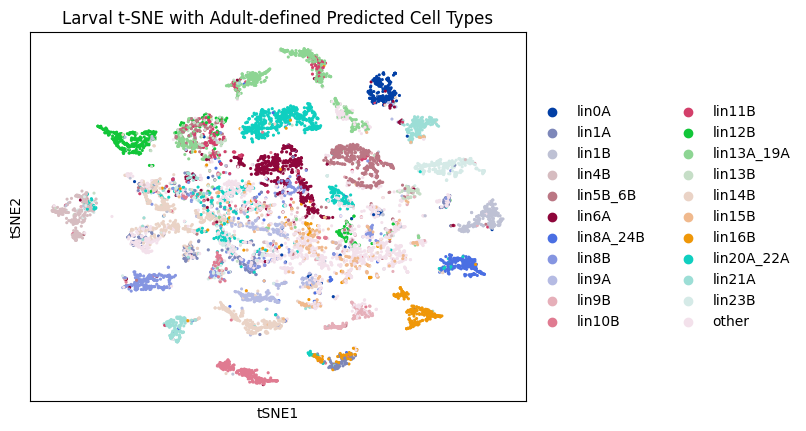

In [ ]:
# Run t-SNE and return the matplotlib figure

fig = sc.pl.tsne(larval_ori, color = 'cell_type',
                 title="Larval t-SNE with Adult-defined Predicted Cell Types",
    size=20,
    return_fig=True)

# Save figure
fig.savefig("scVI_larval_tsne.png", dpi=300, bbox_inches="tight")

# Download to local computer
from google.colab import files
files.download("scVI_larval_tsne.png")

